In [ ]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Forecasting
from prophet import Prophet

# System
import warnings
warnings.filterwarnings("ignore")


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("crisis.csv")

# Check basic info
print(df.shape)
print(df.columns)
print(df['crisis_type'].value_counts())


(2345, 9)
Index(['tweet_id', 'user_id', 'timestamp', 'text', 'crisis_type', 'location',
       'relevance_label', 'urgency_label', 'informative_label'],
      dtype='object')
crisis_type
Pandemic      370
Explosion     361
Landslide     330
Flood         327
Hurricane     324
Fire          320
Earthquake    313
Name: count, dtype: int64


In [ ]:
import re

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)      # remove urls
    t = re.sub(r"@\w+", "", t)         # remove mentions
    t = re.sub(r"#", "", t)            # remove hashtags symbol
    t = re.sub(r"[^a-zA-Z\s]", "", t)  # keep only letters
    t = re.sub(r"\s+", " ", t).strip()
    return t

df['text_clean'] = df['text'].apply(clean_text)
df[['text', 'text_clean']].head()


,text,text_clean
0,Power out and trees down everywhere in Texas. ...,power out and trees down everywhere in texas t...
1,Massive explosion reported at the chemical pla...,massive explosion reported at the chemical pla...
2,Massive earthquake reported near California. B...,massive earthquake reported near california bu...
3,Massive explosion reported at the chemical pla...,massive explosion reported at the chemical pla...
4,"New variant detected in Brazil, authorities is...",new variant detected in brazil authorities iss...


In [ ]:
df.info()
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tweet_id           2345 non-null   int64 
 1   user_id            2345 non-null   object
 2   timestamp          2345 non-null   object
 3   text               2345 non-null   object
 4   crisis_type        2345 non-null   object
 5   location           2345 non-null   object
 6   relevance_label    2345 non-null   int64 
 7   urgency_label      2345 non-null   object
 8   informative_label  2345 non-null   object
 9   text_clean         2345 non-null   object
dtypes: int64(2), object(8)
memory usage: 183.3+ KB
tweet_id             0
user_id              0
timestamp            0
text                 0
crisis_type          0
location             0
relevance_label      0
urgency_label        0
informative_label    0
text_clean           0
dtype: int64


In [ ]:
df.head()

,tweet_id,user_id,timestamp,text,crisis_type,location,relevance_label,urgency_label,informative_label,text_clean
0,1,u2824,2024-02-07 11:09,Power out and trees down everywhere in Texas. ...,Hurricane,Texas,1,Low,Not informative,power out and trees down everywhere in texas t...
1,2,u1409,2023-12-13 14:47,Massive explosion reported at the chemical pla...,Explosion,Texas,1,Medium,Not informative,massive explosion reported at the chemical pla...
2,3,u5506,2023-02-10 20:40,Massive earthquake reported near California. B...,Earthquake,California,0,High,Informative,massive earthquake reported near california bu...
3,4,u5012,2024-04-08 15:58,Massive explosion reported at the chemical pla...,Explosion,Florida,1,High,Unsure,massive explosion reported at the chemical pla...
4,5,u4657,2023-01-07 21:09,"New variant detected in Brazil, authorities is...",Pandemic,Brazil,0,Medium,Not informative,new variant detected in brazil authorities iss...


In [ ]:
# Drop the original text column
df = df.drop('text', axis=1)

# Rename text_clean to text
df = df.rename(columns={'text_clean': 'text'})

# Check result
print(df.columns)
df.head()


Index(['tweet_id', 'user_id', 'timestamp', 'crisis_type', 'location',
       'relevance_label', 'urgency_label', 'informative_label', 'text'],
      dtype='object')


,tweet_id,user_id,timestamp,crisis_type,location,relevance_label,urgency_label,informative_label,text
0,1,u2824,2024-02-07 11:09,Hurricane,Texas,1,Low,Not informative,power out and trees down everywhere in texas t...
1,2,u1409,2023-12-13 14:47,Explosion,Texas,1,Medium,Not informative,massive explosion reported at the chemical pla...
2,3,u5506,2023-02-10 20:40,Earthquake,California,0,High,Informative,massive earthquake reported near california bu...
3,4,u5012,2024-04-08 15:58,Explosion,Florida,1,High,Unsure,massive explosion reported at the chemical pla...
4,5,u4657,2023-01-07 21:09,Pandemic,Brazil,0,Medium,Not informative,new variant detected in brazil authorities iss...


In [ ]:




# Reorder columns: make text the 4th column
cols = list(df.columns)
# Remove 'text' from list and insert at index 3 (0-based)
cols.insert(3, 'text')
df = df[cols]

# Check result
print(df.columns)


Index(['tweet_id', 'user_id', 'timestamp', 'text', 'crisis_type', 'location',
       'relevance_label', 'urgency_label', 'informative_label', 'text'],
      dtype='object')


In [ ]:
df.head()

,tweet_id,user_id,timestamp,text,crisis_type,location,relevance_label,urgency_label,informative_label,text
0,1,u2824,2024-02-07 11:09,power out and trees down everywhere in texas t...,Hurricane,Texas,1,Low,Not informative,power out and trees down everywhere in texas t...
1,2,u1409,2023-12-13 14:47,massive explosion reported at the chemical pla...,Explosion,Texas,1,Medium,Not informative,massive explosion reported at the chemical pla...
2,3,u5506,2023-02-10 20:40,massive earthquake reported near california bu...,Earthquake,California,0,High,Informative,massive earthquake reported near california bu...
3,4,u5012,2024-04-08 15:58,massive explosion reported at the chemical pla...,Explosion,Florida,1,High,Unsure,massive explosion reported at the chemical pla...
4,5,u4657,2023-01-07 21:09,new variant detected in brazil authorities iss...,Pandemic,Brazil,0,Medium,Not informative,new variant detected in brazil authorities iss...


In [ ]:
# Drop the last column (duplicate 'text')
df = df.loc[:, ~df.columns.duplicated()]

# Verify the columns
print(df.columns)


Index(['tweet_id', 'user_id', 'timestamp', 'text', 'crisis_type', 'location',
       'relevance_label', 'urgency_label', 'informative_label'],
      dtype='object')


In [ ]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tweet_id           2345 non-null   int64 
 1   user_id            2345 non-null   object
 2   timestamp          2345 non-null   object
 3   text               2345 non-null   object
 4   crisis_type        2345 non-null   object
 5   location           2345 non-null   object
 6   relevance_label    2345 non-null   int64 
 7   urgency_label      2345 non-null   object
 8   informative_label  2345 non-null   object
dtypes: int64(2), object(7)
memory usage: 165.0+ KB
None
tweet_id             0
user_id              0
timestamp            0
text                 0
crisis_type          0
location             0
relevance_label      0
urgency_label        0
informative_label    0
dtype: int64


In [ ]:
df['text'].head()

,text
0,power out and trees down everywhere in texas t...
1,massive explosion reported at the chemical pla...
2,massive earthquake reported near california bu...
3,massive explosion reported at the chemical pla...
4,new variant detected in brazil authorities iss...


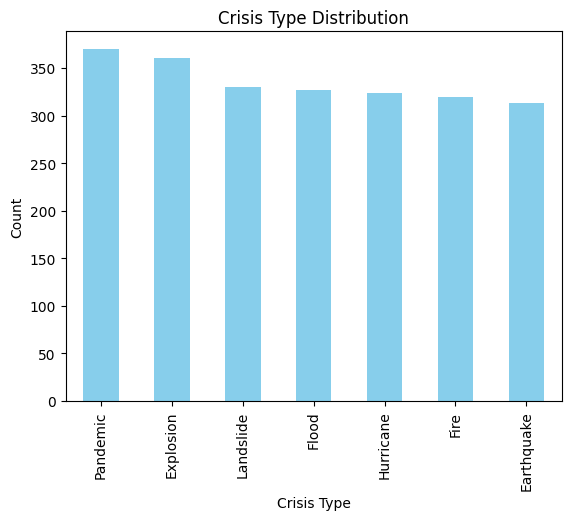

In [ ]:
import matplotlib.pyplot as plt

df['crisis_type'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Crisis Type Distribution")
plt.xlabel("Crisis Type")
plt.ylabel("Count")
plt.show()


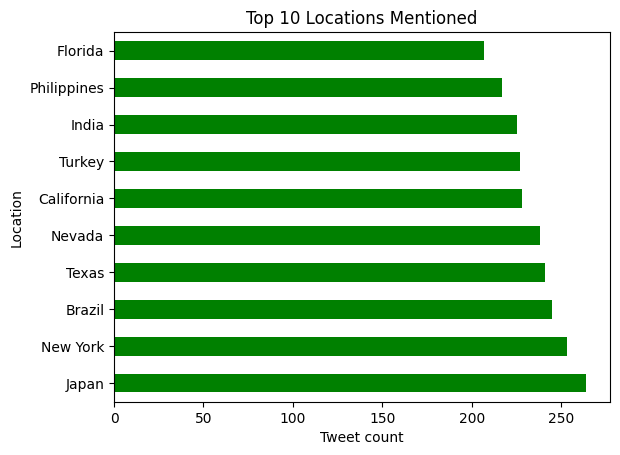

In [ ]:
df['location'].value_counts().head(10).plot(kind='barh', color='green')
plt.title("Top 10 Locations Mentioned")
plt.xlabel("Tweet count")
plt.ylabel("Location")
plt.show()


In [ ]:
# ============================================
# STEP 5: Split Data
# ============================================
X = df['text']
y = df[['crisis_type','location']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# ============================================
# STEP 6: Feature Engineering (TF-IDF)
# ============================================
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
from sklearn.multioutput import MultiOutputClassifier

# ============================================
# STEP 6: Train Multiple Multi-Output Models
# ============================================

models = {
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    "Naive Bayes": MultiOutputClassifier(MultinomialNB()),
    "SVM": MultiOutputClassifier(LinearSVC()),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)  # RF supports multi-output natively
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)  # y_train has 2 columns
    y_pred = model.predict(X_test_tfidf)

    # Calculate accuracy for each label separately
    acc_crisis = accuracy_score(y_test['crisis_type'], y_pred[:, 0])
    acc_location = accuracy_score(y_test['location'], y_pred[:, 1])

    # Store combined report
    results[name] = (acc_crisis, acc_location)

    print(f"\n==== {name} ====")
    print(f"Crisis Type Accuracy : {acc_crisis:.4f}")
    print(f"Location Accuracy    : {acc_location:.4f}")
    print("\nCrisis Type Report:")
    print(classification_report(y_test['crisis_type'], y_pred[:, 0]))
    print("\nLocation Report:")
    print(classification_report(y_test['location'], y_pred[:, 1]))



==== Logistic Regression ====
Crisis Type Accuracy : 1.0000
Location Accuracy    : 1.0000

Crisis Type Report:
              precision    recall  f1-score   support

  Earthquake       1.00      1.00      1.00        63
   Explosion       1.00      1.00      1.00        72
        Fire       1.00      1.00      1.00        64
       Flood       1.00      1.00      1.00        65
   Hurricane       1.00      1.00      1.00        64
   Landslide       1.00      1.00      1.00        66
    Pandemic       1.00      1.00      1.00        75

    accuracy                           1.00       469
   macro avg       1.00      1.00      1.00       469
weighted avg       1.00      1.00      1.00       469


Location Report:
              precision    recall  f1-score   support

      Brazil       1.00      1.00      1.00        48
  California       1.00      1.00      1.00        46
     Florida       1.00      1.00      1.00        42
       India       1.00      1.00      1.00        46
  

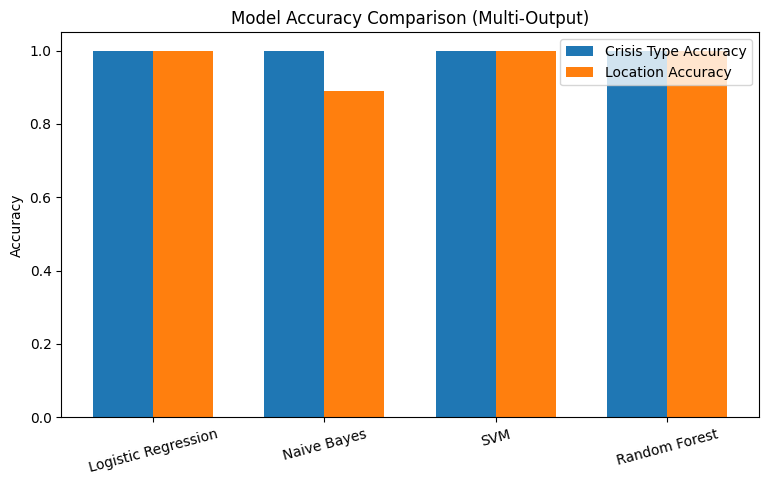

In [ ]:
# ============================================
# STEP 7: Compare Model Accuracies
# ============================================
import numpy as np

model_names = list(results.keys())
crisis_acc = [results[m][0] for m in model_names]
location_acc = [results[m][1] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, crisis_acc, width, label="Crisis Type Accuracy")
plt.bar(x + width/2, location_acc, width, label="Location Accuracy")

plt.xticks(x, model_names, rotation=15)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Multi-Output)")
plt.legend()
plt.show()


In [ ]:
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")


In [ ]:
def extract_location(text):
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["GPE", "LOC"]:  # GPE = Countries, Cities, States
            return ent.text
    return None


In [ ]:
def predict_crisis(text):
    # Convert text to TF-IDF
    text_tfidf = vectorizer.transform([text])

    # Best model
    best_model = models["Random Forest"]

    # Predict crisis + location (model output)
    pred = best_model.predict(text_tfidf)[0]
    crisis_pred = pred[0]

    # Extract location using NER
    ner_location = extract_location(text)

    # Final location logic
    if ner_location:
        final_location = ner_location   # use NER-detected location
    else:
        final_location = "Unknown"      # instead of model predicted wrong place

    # Display
    print("\n🔍 INPUT TEXT:", text)
    print("🆔 Predicted Crisis Type:", crisis_pred)
    print("📍 Predicted Location:", final_location)


In [ ]:
predict_crisis("Huge fire near the marketplace, people are being evacuated!")
predict_crisis("Flood alerts issued in Mumbai, stay indoors and safe!")
predict_crisis("Explosion reported at refinery plant, rescue teams deployed.")
predict_crisis("Vaccination centers in Nevada are overwhelmed with long queues.")



🔍 INPUT TEXT: Huge fire near the marketplace, people are being evacuated!
🆔 Predicted Crisis Type: Fire
📍 Predicted Location: Unknown

🔍 INPUT TEXT: Flood alerts issued in Mumbai, stay indoors and safe!
🆔 Predicted Crisis Type: Flood
📍 Predicted Location: Mumbai

🔍 INPUT TEXT: Explosion reported at refinery plant, rescue teams deployed.
🆔 Predicted Crisis Type: Explosion
📍 Predicted Location: Unknown

🔍 INPUT TEXT: Vaccination centers in Nevada are overwhelmed with long queues.
🆔 Predicted Crisis Type: Pandemic
📍 Predicted Location: Nevada
